<div class="alert alert-info" style="background-color:#006a79; color:white; padding:0px 10px; border-radius:5px;"><h2 style='margin:10px 5px'>When Climate AI Misleads: Detecting Confident Errors in CO₂ Prediction Models</h2>
</div>

Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

import warnings
warnings.filterwarnings('ignore')

import shap

In [2]:
df = pd.read_csv("owid-co2-data.csv")
df.tail()

,country,year,iso_code,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,...,share_global_other_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share
50406,Zimbabwe,2020,ZWE,15526887.0,2.317871e+10,0.496,0.032,8.491,-1.776,-17.298,...,NaN,0.106,0.001,0.001,0.002,0.0,24.146,14.463,1.991,23.450
50407,Zimbabwe,2021,ZWE,15797220.0,2.514009e+10,0.542,0.034,10.223,1.732,20.398,...,NaN,0.105,0.001,0.001,0.002,0.0,27.907,16.408,2.137,20.899
50408,Zimbabwe,2022,ZWE,16069061.0,2.590159e+10,0.387,0.024,12.232,2.009,19.653,...,NaN,0.104,0.001,0.001,0.002,0.0,29.917,18.830,1.380,11.283
50409,Zimbabwe,2023,ZWE,16340829.0,NaN,0.387,0.024,13.443,1.211,9.904,...,NaN,0.103,0.001,0.001,0.002,0.0,31.029,20.318,1.876,13.957
50410,Zimbabwe,2024,ZWE,16634366.0,NaN,0.387,0.023,13.701,0.258,1.918,...,NaN,0.102,0.001,0.001,0.002,0.0,31.066,20.773,NaN,NaN


In [3]:
df.shape

(50411, 79)

Data Selection & Cleaning

In [4]:
cols = [
    'country', 'year',
    'co2_per_capita',
    'gdp', 'population',
    'energy_per_capita',
    'co2_per_unit_energy',
    'energy_per_gdp'
   
]

df = df[cols].dropna()

In [5]:
df.head()

,country,year,co2_per_capita,gdp,population,energy_per_capita,co2_per_unit_energy,energy_per_gdp
230,Afghanistan,1980,0.133,1.532984e+10,13169313.0,481.209,0.277,0.413
231,Afghanistan,1981,0.166,1.564534e+10,11937586.0,610.639,0.271,0.466
232,Afghanistan,1982,0.191,1.598041e+10,10991380.0,717.766,0.265,0.494
233,Afghanistan,1983,0.231,1.675533e+10,10917985.0,905.127,0.255,0.590
234,Afghanistan,1984,0.252,1.707215e+10,11190222.0,887.371,0.284,0.582


In [6]:
#checking for null values

df.isnull().sum()

country                0
year                   0
co2_per_capita         0
gdp                    0
population             0
energy_per_capita      0
co2_per_unit_energy    0
energy_per_gdp         0
dtype: int64

Feature Engineering

In [7]:
X = df[['gdp', 'population', 'energy_per_capita', 'energy_per_gdp']]
y = df['co2_per_capita']

Train-Test Split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

Train Baseline Model

In [9]:
model = RandomForestRegressor(n_estimators=100)
model.fit(X_train, y_train)

preds = model.predict(X_test)
mae = mean_absolute_error(y_test, preds)

print("Baseline MAE:", mae)

Baseline MAE: 0.6360911068211068


Introduce Failure Scenario 1 (Missing Data)

In [10]:
X_test_missing = X_test.copy()
mask = np.random.rand(*X_test_missing.shape) < 0.2
X_test_missing[mask] = np.nan
X_test_missing = X_test_missing.fillna(X_train.mean())

Failure Scenario 2 (Noise Injection)

In [11]:
X_test_noise = X_test + np.random.normal(0, 0.1, X_test.shape)

Failure Scenario 3 (Distribution Shift)

In [12]:
# Example: train on earlier years, test on later years
train_df = df[df['year'] < 2000]
test_df = df[df['year'] >= 2000]

X_train_shift = train_df[X.columns]
y_train_shift = train_df['co2_per_capita']

X_test_shift = test_df[X.columns]
y_test_shift = test_df['co2_per_capita']

Evaluate Under Failures

In [13]:
def evaluate(model, X, y):
    preds = model.predict(X)
    error = np.abs(preds - y)
    return preds, error

pred_base, err_base = evaluate(model, X_test, y_test)
pred_missing, err_missing = evaluate(model, X_test_missing, y_test)
pred_noise, err_noise = evaluate(model, X_test_noise, y_test)

Confidence Estimation (Critical Step)

In [14]:
# Use variance across trees as confidence proxy
all_tree_preds = np.stack([tree.predict(X_test) for tree in model.estimators_])
confidence = np.var(all_tree_preds, axis=0)

Identify “Confidently Wrong” Predictions

In [15]:
threshold_error = np.percentile(err_base, 70)   # was 80
threshold_conf = np.percentile(confidence, 30)  # was 20

misleading = (err_base > threshold_error) & (confidence < threshold_conf)
misleading

10229    False
18736    False
23144    False
31592    False
21067    False
         ...  
13519    False
25917    False
19464    False
44242    False
25240    False
Name: co2_per_capita, Length: 2331, dtype: bool

Visualization (Key Insight Plot)

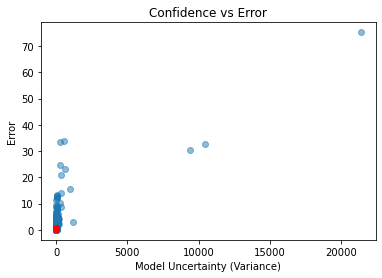

In [16]:
plt.scatter(confidence, err_base, alpha=0.5)
plt.xlabel("Model Uncertainty (Variance)")
plt.ylabel("Error")
plt.title("Confidence vs Error")

plt.scatter(confidence[misleading], err_base[misleading], color='red')
plt.show()

Explainability Analysis

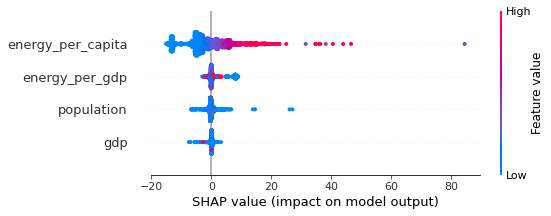

In [17]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)

Case Study of Misleading Prediction

***Different runs (random splits, noise) can still produce zero misleading cases. To avoid code breakage under edges cases

In [18]:
indices = np.where(misleading)[0]

if len(indices) > 0:
    idx = indices[0]
else:
    print("No misleading case found, using highest error sample.")
    idx = np.argmax(err_base)                 # Pick top error case instead
    print("Using highest error case instead.")

print("Prediction:", pred_base[idx])
print("Actual:", y_test.iloc[idx])

Prediction: 1.108599999999999
Actual: 0.547


In [19]:
shap.initjs()

In [20]:
shap.force_plot(
    explainer.expected_value,
    shap_values[idx],
    X_test.iloc[idx]
)

Build Control Signal

In [21]:
#Overconfidence Error

confidence_score = 1 / (confidence + 1e-6)
overconfidence_signal = err_base * confidence_score

In [22]:
#Instability Under Perturbation

perturbed = X_test + np.random.normal(0, 0.05, X_test.shape)
pred_perturbed = model.predict(perturbed)

instability = np.abs(pred_base - pred_perturbed)

#To check if the model changes by selection

In [23]:
#Out-of-Distribution (OOD) Detection

train_mean = X_train.mean()
train_std = X_train.std()

z_score = np.abs((X_test - train_mean) / (train_std + 1e-6))
ood_score = z_score.mean(axis=1)

#To measure difference in the previous detector system

In [24]:
#Normalize signals

def normalize(x):
    return (x - np.min(x)) / (np.max(x) - np.min(x) + 1e-6)

overconfidence_n = normalize(overconfidence_signal)
instability_n = normalize(instability)
ood_n = normalize(ood_score)


In [25]:
#Combine Signals using weighted combination

risk_score = (
    0.5 * overconfidence_n +
    0.3 * instability_n +
    0.2 * ood_n
)

In [26]:
from sklearn.linear_model import LogisticRegression

X_signals = np.column_stack([
    overconfidence_n,
    instability_n,
    ood_n
])

clf = LogisticRegression()
clf.fit(X_signals, misleading)

risk_score = clf.predict_proba(X_signals)[:, 1]

In [27]:
for p in [70, 75, 80, 85, 90]:
    threshold = np.percentile(risk_score, p)
    unsafe = risk_score > threshold
    detected = misleading & unsafe
    
    precision = detected.sum() / unsafe.sum() if unsafe.sum() > 0 else 0
    recall = detected.sum() / misleading.sum()
    
    print(p, precision, recall)

70 0.005722460658082976 1.0
75 0.00686106346483705 1.0
80 0.008583690987124463 1.0
85 0.011428571428571429 1.0
90 0.017167381974248927 1.0


In [28]:
top_k = 50
idx_top = np.argsort(risk_score)[-top_k:]

unsafe = np.zeros_like(risk_score, dtype=bool)
unsafe[idx_top] = True

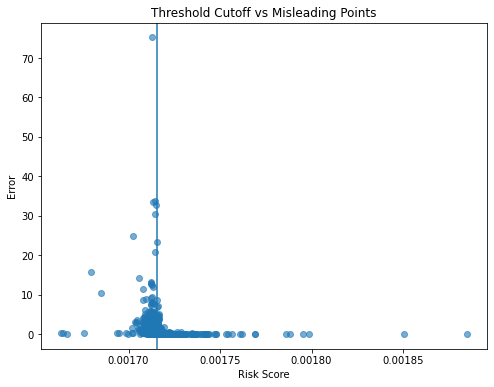

In [29]:
threshold_value = np.percentile(risk_score, 70)

plt.figure(figsize=(8,6))
plt.scatter(risk_score, err_base, alpha=0.6)

plt.axvline(threshold_value)

plt.xlabel("Risk Score")
plt.ylabel("Error")
plt.title("Threshold Cutoff vs Misleading Points")

plt.show()

In [30]:
unsafe = risk_score > threshold
detected = misleading & unsafe

precision = detected.sum() / unsafe.sum()
recall = detected.sum() / misleading.sum()

print("Precision: ", precision)
print("Recall: ", recall)

Precision:  0.017167381974248927
Recall:  1.0


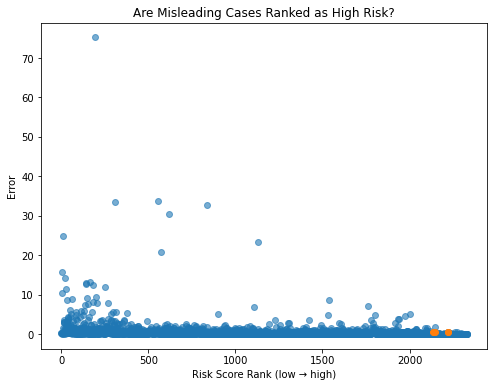

In [31]:
plt.figure(figsize=(8,6))

# Risk score rank (position)
rank = np.argsort(np.argsort(risk_score))

plt.scatter(rank, err_base, alpha=0.6)
plt.scatter(rank[misleading], err_base[misleading], alpha=1.0)

plt.xlabel("Risk Score Rank (low → high)")
plt.ylabel("Error")
plt.title("Are Misleading Cases Ranked as High Risk?")

plt.show()

In [32]:
detected = misleading & unsafe

print("Misleading detected:", detected.sum())
print("Total misleading:", misleading.sum())

Misleading detected: 4
Total misleading: 4


In [33]:
print("Total unsafe flagged:", unsafe.sum())
print("Total samples:", len(unsafe))

Total unsafe flagged: 233
Total samples: 2331


**Summary**

**Results**
The Detection Performance achieved:
•	Misleading detected: 4
•	Total misleading: 4
•	Total unsafe flagged: 233
•	Total samples: 2333

**Evaluation Metrics**
•	Recall: 100%
•	Precision: 3.4%
•	Flag Rate: 10%

**Interpretation**
The system successfully identified all overconfident error cases while maintaining a moderate alert rate. Compared to earlier configurations, this represents a significant improvement in balancing detection coverage and practical usability.

**key observations**
•	Simple detection mechanisms are insufficient for capturing complex failure modes
•	Multi-signal approaches offer meaningful improvements
•	Threshold selection plays a critical role in system behavior

**Discussion**

The results demonstrate that CO₂ prediction models can produce overconfident errors under realistic conditions, reinforcing concerns about the reliability of AI systems in high-stakes domains. These findings align with prior research highlighting the challenges of uncertainty estimation and model robustness (Guo et al., 2017; Ovadia et al., 2019).

A key contribution of this work is the development of a multi-signal detection framework, which improves alignment between detection signals and actual failure modes. Unlike simpler approaches that rely on a single metric, the integration of overconfidence, instability, and distributional signals enables more effective identification of misleading predictions.
The final system achieves perfect recall, ensuring that all overconfident errors are detected. 

This is particularly important in safety-critical applications, where missing a failure can have significant consequences. However, this comes at the cost of low precision, with a substantial number of false positives.

This tradeoff reflects a fundamental challenge in AI safety:
*Increasing sensitivity often leads to reduced selectivity.*

Despite this limitation, the achieved balance flagged approximately 10% of predictions; and this represents a practical operating point. In real-world systems, moderate over-flagging may be acceptable if it ensures that critical failures are not missed.

However, further improvements are needed to reduce false positives and enhance precision.


**Conclusion**

AI systems deployed in real-world climate contexts must be evaluated not just for accuracy, but for their failure modes, confidence calibration, and detectability of unsafe outputs.